Second RNN GridWorld Experiment
Goal: Increase the number of trajectories (batches) used for training in the RNN

Results observation: the increase of trajectories in the training set seems to have equalled the field between the MLP and the RNN, providing similar training and validation loss for both architectures. Interestingly, manipulating the action probabilities to favor turning over forward movement or stopping seems to have widen the gap between them. This is not surprising, since turning changes the observation environment significantly more than forward movement does.

In [1]:
%load_ext autoreload
%autoreload 2

Imports

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
    
from IPython.display import display, Markdown
import functions.trajectories as trajectories
import functions.NN_models as NN_models
import functions.gridworld as gridworld
import functions.model_training_evaluator as model_training_evaluator
import functions.dataset_generator as dataset_generator
import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt

print(sys.executable)
print(torch.__version__)

/home/seblee/miniconda3/envs/main/bin/python
2.14.0+cu130


State variables

In [3]:

HEIGHT = 29
WIDTH = 36
VIEW_SIZE = 5

START_X = 7
START_Y = 7
START_DIRECTION = 2

N_STEPS = 500
N_TRAJ = 20

ACTION_PROBS = [0.6, 0.15, 0.15, 0.1]
ACTION_PROBS_TURN_HEAVY = [0.3, 0.35, 0.35, 0.0]

SEED = 42
TRAINER_MOVE_SEED = 100
TRAINER_START_SEED = 150
VALIDATOR_MOVE_SEED = 300
VALIDATOR_START_SEED = 350

TEST_SEED = 123
TEST_STEPS = 200

TRAINING_EPOCHS = 3000

Gridworld Creation

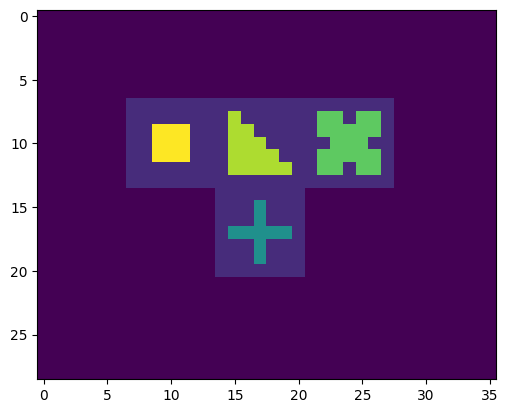

In [4]:
grid = gridworld.GridWorld(HEIGHT, WIDTH)
grid.add_rectangle_region(7, 14, 7, 28)
grid.add_rectangle_region(14, 21, 14, 21)
grid.add_square_shape(9, 9, 3, 7)
grid.add_triangle_shape(8, 15, 5, 0, 6)
grid.add_square_shape(9, 23, 3, 5)
grid.add_square_shape(8, 22, 2, 5)
grid.add_square_shape(11, 22, 2, 5)
grid.add_square_shape(11, 25, 2, 5)
grid.add_square_shape(8, 25, 2, 5)
grid.add_rectangle_shape(15, 17, 5, 1, 3)
grid.add_rectangle_shape(17, 15, 1, 5, 3)
plt.imshow(grid.grid)


NN Training and Validation

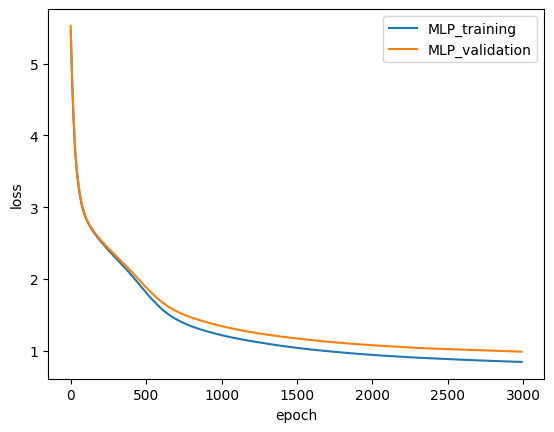

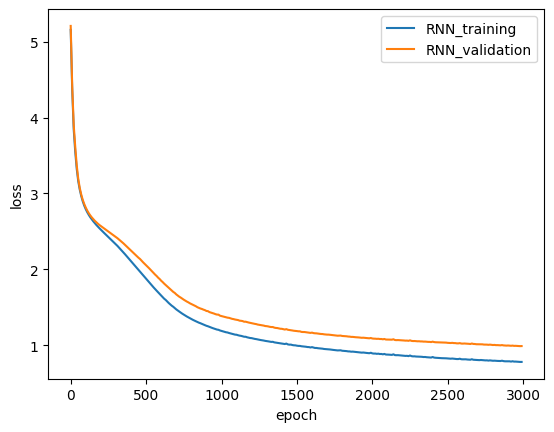

,Trainer,Validator
RNN,0.781012,0.989776
MLP,0.840692,0.983709
Baseline,4.591728,4.676160


In [5]:
#Generate trainer and validator agents

trainer_inputs_stack, trainer_target_stack, trainer_agent_list = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS, VIEW_SIZE, N_STEPS, N_TRAJ, TRAINER_MOVE_SEED, random_start=True, start_seed_start=TRAINER_START_SEED)
validator_inputs_stack, validator_target_stack, validator_agent_list = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS, VIEW_SIZE, N_STEPS, 5, VALIDATOR_MOVE_SEED, random_start=True, start_seed_start=VALIDATOR_START_SEED)

#Train MLP

INPUT_SIZE = trainer_inputs_stack.shape[2]
OUTPUT_SIZE = trainer_target_stack.shape[2]
HIDDEN_SIZE = 64     

model_MLP = NN_models.SimpleMLP(INPUT_SIZE, OUTPUT_SIZE, HIDDEN_SIZE, "relu")
MLP_loss_info = model_training_evaluator.model_training(model_MLP, trainer_inputs_stack, trainer_target_stack, validator_inputs_stack, validator_target_stack, TRAINING_EPOCHS)

model_training_evaluator.plot_training_result(MLP_loss_info, "epoch", "loss", "MLP_training", "MLP_validation")

#Train RNN

model_RNN = NN_models.BasicRNN(INPUT_SIZE, OUTPUT_SIZE, HIDDEN_SIZE, "relu")
RNN_loss_info = model_training_evaluator.model_training(model_RNN, trainer_inputs_stack, trainer_target_stack, validator_inputs_stack, validator_target_stack, TRAINING_EPOCHS)

model_training_evaluator.plot_training_result(RNN_loss_info, "epoch", "loss", "RNN_training", "RNN_validation")

#Baseline Loss Evaluation

trainer_baseline = model_training_evaluator.baseline_evaluation(trainer_inputs_stack, trainer_target_stack)
validator_baseline = model_training_evaluator.baseline_evaluation(validator_inputs_stack, validator_target_stack)

loss_table = []

RNN_final_loss = []
MLP_final_loss = []
baseline_loss = []

RNN_final_loss.append(RNN_loss_info[1][-1])
RNN_final_loss.append(RNN_loss_info[2][-1])
MLP_final_loss.append(MLP_loss_info[1][-1])
MLP_final_loss.append(MLP_loss_info[2][-1])
baseline_loss.append(trainer_baseline)
baseline_loss.append(validator_baseline)

loss_table.append(RNN_final_loss)
loss_table.append(MLP_final_loss)
loss_table.append(baseline_loss)

training_results = pd.DataFrame(
    loss_table,
    index = ("RNN", "MLP", "Baseline"),
    columns = ("Trainer", "Validator")
)

training_results


Turn-Heavy Trajectory run

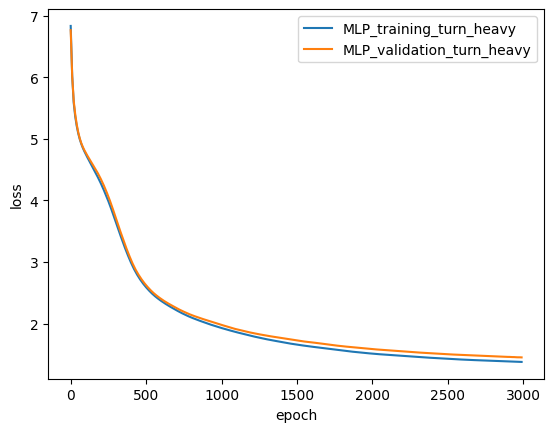

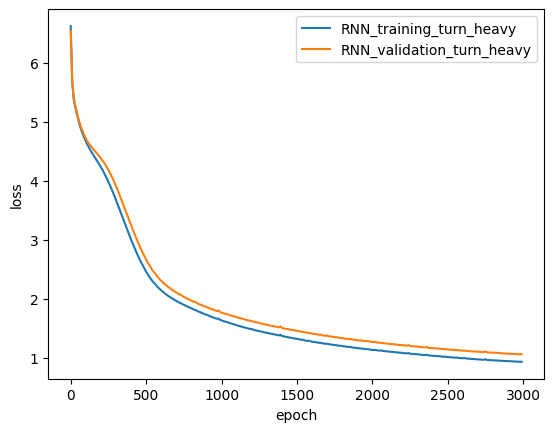

,Trainer,Validator
RNN,0.934687,1.065173
MLP,1.375916,1.449427
Baseline,9.019744,9.019744


In [6]:
#Generate turn heavy trainer and validator agents

trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy, trainer_agent_list_turn_heavy = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS_TURN_HEAVY, VIEW_SIZE, N_STEPS, N_TRAJ, TRAINER_MOVE_SEED, random_start=True, start_seed_start=TRAINER_START_SEED)
validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy, validator_agent_list_turn_heavy = dataset_generator.generate_dataset(grid, trajectories.random_policy, ACTION_PROBS_TURN_HEAVY, VIEW_SIZE, N_STEPS, 5, VALIDATOR_MOVE_SEED, random_start=True, start_seed_start=VALIDATOR_START_SEED)

#Train MLP

INPUT_SIZE_TURN_HEAVY = trainer_inputs_stack_turn_heavy.shape[2]
OUTPUT_SIZE_TURN_HEAVY = trainer_target_stack_turn_heavy.shape[2]
HIDDEN_SIZE_TURN_HEAVY = 64     

model_MLP_turn_heavy = NN_models.SimpleMLP(INPUT_SIZE_TURN_HEAVY, OUTPUT_SIZE_TURN_HEAVY, HIDDEN_SIZE_TURN_HEAVY, "relu")
MLP_turn_heavy_loss_info = model_training_evaluator.model_training(model_MLP_turn_heavy, trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy, validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy, TRAINING_EPOCHS)
model_training_evaluator.plot_training_result(MLP_turn_heavy_loss_info, "epoch", "loss", "MLP_training_turn_heavy", "MLP_validation_turn_heavy")

#Train RNN

model_RNN_turn_heavy = NN_models.BasicRNN(INPUT_SIZE_TURN_HEAVY, OUTPUT_SIZE_TURN_HEAVY, HIDDEN_SIZE_TURN_HEAVY, "relu")
RNN_turn_heavy_loss_info = model_training_evaluator.model_training(model_RNN_turn_heavy, trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy, validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy, TRAINING_EPOCHS)
model_training_evaluator.plot_training_result(RNN_turn_heavy_loss_info, "epoch", "loss", "RNN_training_turn_heavy", "RNN_validation_turn_heavy")

#Baseline Loss Evaluation

trainer_baseline_turn_heavy = model_training_evaluator.baseline_evaluation(validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy)
validator_baseline_turn_heavy = model_training_evaluator.baseline_evaluation(validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy)


loss_table_turn_heavy = []

RNN_final_loss_turn_heavy = []
MLP_final_loss_turn_heavy = []
baseline_loss_turn_heavy = []

RNN_final_loss_turn_heavy.append(RNN_turn_heavy_loss_info[1][-1])
RNN_final_loss_turn_heavy.append(RNN_turn_heavy_loss_info[2][-1])
MLP_final_loss_turn_heavy.append(MLP_turn_heavy_loss_info[1][-1])
MLP_final_loss_turn_heavy.append(MLP_turn_heavy_loss_info[2][-1])
baseline_loss_turn_heavy.append(trainer_baseline_turn_heavy)
baseline_loss_turn_heavy.append(validator_baseline_turn_heavy)

loss_table_turn_heavy.append(RNN_final_loss_turn_heavy)
loss_table_turn_heavy.append(MLP_final_loss_turn_heavy)
loss_table_turn_heavy.append(baseline_loss_turn_heavy)

training_results_turn_heavy = pd.DataFrame(
    loss_table_turn_heavy,
    index = ("RNN", "MLP", "Baseline"),
    columns = ("Trainer", "Validator")
)

training_results_turn_heavy

In [11]:
loss_standard_vs_turn_heavy = []

loss_standard_vs_turn_heavy.append(RNN_final_loss)
loss_standard_vs_turn_heavy.append(RNN_final_loss_turn_heavy)
loss_standard_vs_turn_heavy.append(MLP_final_loss)
loss_standard_vs_turn_heavy.append(MLP_final_loss_turn_heavy)

results_standard_vs_turn_heavy = pd.DataFrame(

    loss_standard_vs_turn_heavy,

    index = ("RNN, standard", "RNN, turn heavy", "MLP, standard", "MLP, turn heavy"),
    columns = ("Trainer", "Validator")
)

results_standard_vs_turn_heavy
#print(results_standard_vs_turn_heavy.to_markdown(index=True, floatfmt=".3f"))

,Trainer,Validator
"RNN, standard",0.781012,0.989776
"RNN, turn heavy",0.934687,1.065173
"MLP, standard",0.840692,0.983709
"MLP, turn heavy",1.375916,1.449427


Validator Error per Action Type

Turn Heavy per-action MSE loss

In [8]:
results_array_turn_heavy = []

trainer_RNN_action_losses_turn_heavy = model_training_evaluator.evaluator_per_action(model_RNN_turn_heavy, trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy)
validator_RNN_action_losses_turn_heavy = model_training_evaluator.evaluator_per_action(model_RNN_turn_heavy, validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy)

trainer_MLP_action_losses_turn_heavy = model_training_evaluator.evaluator_per_action(model_MLP_turn_heavy, trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy)
validator_MLP_action_losses_turn_heavy = model_training_evaluator.evaluator_per_action(model_MLP_turn_heavy, validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy)

results_array_turn_heavy.append(trainer_RNN_action_losses_turn_heavy)
results_array_turn_heavy.append(trainer_MLP_action_losses_turn_heavy)
results_array_turn_heavy.append(validator_RNN_action_losses_turn_heavy)
results_array_turn_heavy.append(validator_MLP_action_losses_turn_heavy)

results_turn_heavy = pd.DataFrame(
    results_array_turn_heavy,
    index = ["trainer, RNN", "trainer, MLP", "validator, RNN", "validator, MLP"],
    columns = ["Forward", "Left", "Right", "Stop"]
)

results_turn_heavy

#print(results_turn_heavy.to_markdown(index=True, floatfmt=".3f"))

No samples for 3
No samples for 3
No samples for 3
No samples for 3


,Forward,Left,Right,Stop
"trainer, RNN",0.598400,1.099471,1.050350,None
"trainer, MLP",0.579936,1.742406,1.691543,None
"validator, RNN",0.614470,1.270093,1.255200,None
"validator, MLP",0.575784,1.863544,1.831155,None


Standard per-action MSE loss

In [9]:
results_array = []

trainer_RNN_action_losses = model_training_evaluator.evaluator_per_action(model_RNN, trainer_inputs_stack, trainer_target_stack)
validator_RNN_action_losses = model_training_evaluator.evaluator_per_action(model_RNN, validator_inputs_stack, validator_target_stack)

trainer_MLP_action_losses = model_training_evaluator.evaluator_per_action(model_MLP, trainer_inputs_stack, trainer_target_stack)
validator_MLP_action_losses = model_training_evaluator.evaluator_per_action(model_MLP, validator_inputs_stack, validator_target_stack)

results_array.append(trainer_RNN_action_losses)
results_array.append(trainer_MLP_action_losses)
results_array.append(validator_RNN_action_losses)
results_array.append(validator_MLP_action_losses)

results = pd.DataFrame(
    results_array,
    index = ["trainer, RNN", "trainer, MLP", "validator, RNN", "validator, MLP"],
    columns = ["Forward", "Left", "Right", "Stop"]
)

results

#print(results.to_markdown(index=True, floatfmt=".3f"))

,Forward,Left,Right,Stop
"trainer, RNN",0.317339,1.586087,1.539171,1.196400
"trainer, MLP",0.261030,2.021677,2.043353,0.731295
"validator, RNN",0.439389,1.994591,2.118444,1.391794
"validator, MLP",0.328048,2.415641,2.433317,0.959380


Memoryless RNN: How does RNN perform if the hidden state is reset at every step?

In [10]:
memoryless_results_array = []
trainer_RNN_memoryless_per_action_loss = model_training_evaluator.evaluator_per_action_memoryless(model_RNN, trainer_inputs_stack, trainer_target_stack)
validator_RNN_memoryless_per_action_loss = model_training_evaluator.evaluator_per_action_memoryless(model_RNN, validator_inputs_stack, validator_target_stack)


trainer_RNN_turn_heavy_memoryless_per_action_loss = model_training_evaluator.evaluator_per_action_memoryless(model_RNN, trainer_inputs_stack_turn_heavy, trainer_target_stack_turn_heavy)
validator_RNN_turn_heavy_memoryless_per_action_loss = model_training_evaluator.evaluator_per_action_memoryless(model_RNN, validator_inputs_stack_turn_heavy, validator_target_stack_turn_heavy)

memoryless_results_array.append(trainer_RNN_action_losses)
memoryless_results_array.append(trainer_RNN_memoryless_per_action_loss)
memoryless_results_array.append(trainer_MLP_action_losses)
memoryless_results_array.append(validator_RNN_action_losses)
memoryless_results_array.append(validator_RNN_memoryless_per_action_loss)
memoryless_results_array.append(validator_MLP_action_losses)

results = pd.DataFrame(
    memoryless_results_array,
    index = ["trainer, RNN", "Trainer RNN Memoryless", "trainer, MLP", "validator, RNN", "Validator RNN Memoryless", "Validator, MLP"],
    columns = ["Forward", "Left", "Right", "Stop"]
)

results

No samples for 3
No samples for 3


,Forward,Left,Right,Stop
"trainer, RNN",0.317339,1.586087,1.539171,1.196400
Trainer RNN Memoryless,1.484699,4.372966,4.223192,1.861105
"trainer, MLP",0.261030,2.021677,2.043353,0.731295
"validator, RNN",0.439389,1.994591,2.118444,1.391794
Validator RNN Memoryless,1.599674,4.471939,4.444033,1.987995
"Validator, MLP",0.328048,2.415641,2.433317,0.959380
